In [19]:
import pandas as pd
import seaborn as sns
import statsmodels.api as sm

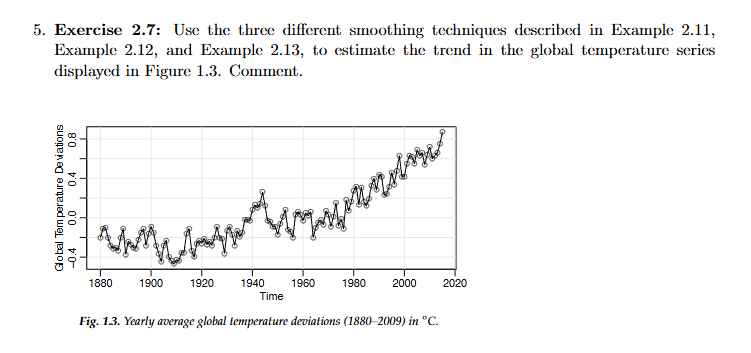

In [20]:
#2.11 - Moving Average
#2.12 - Kernel
#2.13 - Lowess Smoothing

In [21]:
df = pd.read_csv("globtemp.csv")
df.head()

,index,value
0,1880,-0.20
1,1881,-0.11
2,1882,-0.10
3,1883,-0.20
4,1884,-0.28


2.11 Moving Average

In [22]:
from statsmodels.tsa.filters.filtertools import convolution_filter
maWeights = [1/11] * 11
yt = convolution_filter(df['value'], maWeights, nsides=2)

<Axes: xlabel='index', ylabel='value'>

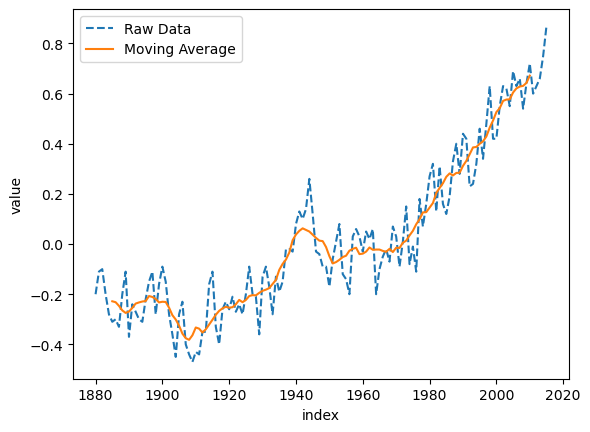

In [23]:
sns.lineplot(x=df['index'], y=df['value'], label = "Raw Data", linestyle="--")
sns.lineplot(x=df['index'], y=yt, label = "Moving Average")

2.12 - Kernel Density Smoothing

In [24]:
kr = sm.nonparametric.KernelReg(
    endog=df["value"], exog=df.index, var_type="c", bw=[5])

In [25]:
vt, z = kr.fit()

[5]


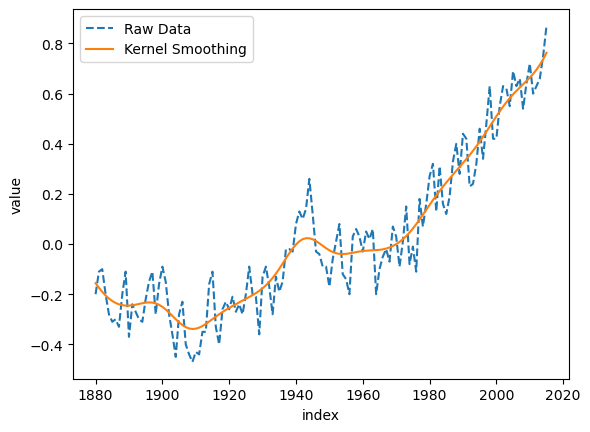

In [26]:
sns.lineplot(x=df['index'], y=df['value'], label = "Raw Data", linestyle="--")
sns.lineplot(x=df['index'], y=vt, label = "Kernel Smoothing")
print(kr.bw)

<Axes: xlabel='index', ylabel='value'>

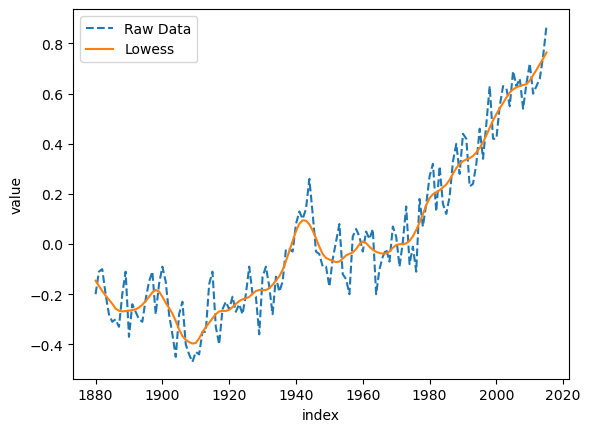

In [27]:
df['Lowess'] = sm.nonparametric.lowess(
    df['value'], df['index'], frac=0.1, return_sorted=False)
sns.lineplot(x=df['index'], y=df['value'], label = "Raw Data", linestyle="--")
sns.lineplot(x=df['index'], y=df['Lowess'], label = "Lowess")

<Axes: xlabel='index', ylabel='value'>

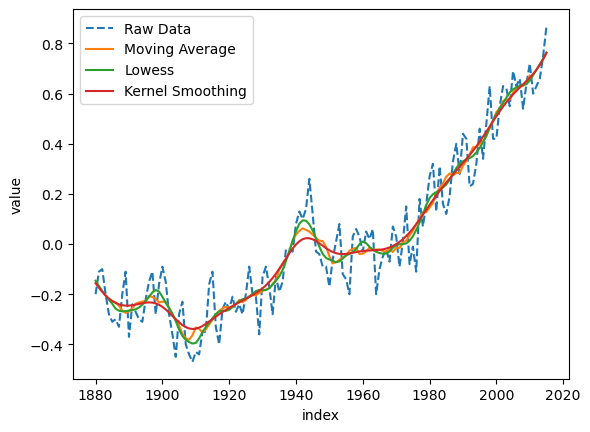

In [28]:
sns.lineplot(x=df['index'], y=df['value'], label = "Raw Data", linestyle="--")
sns.lineplot(x=df['index'], y=yt, label = "Moving Average")
sns.lineplot(x=df['index'], y=df['Lowess'], label = "Lowess")
sns.lineplot(x=df['index'], y=vt, label = "Kernel Smoothing")